In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import pickle
import os
import random
from models.vae_model import TradingVAE, loss_function
from utils.data_loader import fetch_and_prepare_data

In [2]:
SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [3]:
SEQ_LEN = 20
INPUT_DIM = 2
HIDDEN_DIM = 64
LATENT_DIM = 16
EPOCHS = 300
BATCH_SIZE = 64
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
X_train, scaler, _ = fetch_and_prepare_data("^GSPC", "2015-05-01", "2025-05-01", SEQ_LEN)
dataset = TensorDataset(X_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
X_train

[*********************100%***********************]  1 of 1 completed


tensor([[[ 0.2195, -0.9713],
         [-1.0585, -0.2622],
         [-0.4177, -0.2640],
         ...,
         [-0.1424, -1.0836],
         [-0.5790, -0.1275],
         [ 0.1439, -1.0519]],

        [[-1.0585, -0.2622],
         [-0.4177, -0.2640],
         [ 0.2910, -0.3807],
         ...,
         [-0.5790, -0.1275],
         [ 0.1439, -1.0519],
         [-0.1201, -1.0139]],

        [[-0.4177, -0.2640],
         [ 0.2910, -0.3807],
         [ 1.1176, -0.6605],
         ...,
         [ 0.1439, -1.0519],
         [-0.1201, -1.0139],
         [ 0.1490, -0.9628]],

        ...,

        [[-1.7495,  0.4640],
         [ 0.4422,  1.2150],
         [ 0.2917,  0.3844],
         ...,
         [ 1.3893,  1.3302],
         [ 1.6935,  0.6501],
         [ 0.5992,  0.1846]],

        [[ 0.4422,  1.2150],
         [ 0.2917,  0.3844],
         [ 0.5440,  0.1919],
         ...,
         [ 1.6935,  0.6501],
         [ 0.5992,  0.1846],
         [ 0.0219,  0.2061]],

        [[ 0.2917,  0.3844],
       

In [5]:
model = TradingVAE(SEQ_LEN, INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(EPOCHS):
    train_loss = 0
    MAX_BETA = 0.1
    beta = min(MAX_BETA, (epoch / 25.0) * MAX_BETA)

    for batch in dataloader:
        batch_data = batch[0].to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(batch_data)
        loss = loss_function(recon_batch, batch_data, mu, logvar, beta)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

In [6]:
model

TradingVAE(
  (encoder_lstm): LSTM(2, 64, batch_first=True)
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 64, batch_first=True)
  (fc_out): Linear(in_features=64, out_features=2, bias=True)
)

In [10]:
train_loss / len(dataloader.dataset)

21.452852960386178

In [11]:
X_test, _, raw_data = fetch_and_prepare_data("^GSPC", "2025-05-01", "2026-05-01", SEQ_LEN, scaler=scaler)

[*********************100%***********************]  1 of 1 completed


In [13]:
model = model.to('cpu')
with torch.no_grad():
    recon_data, mu, logvar = model(X_test)
    test_loss = loss_function(recon_data, X_test, mu, logvar)

    z_random = torch.randn(len(X_test), LATENT_DIM)
    generated_data = model.decode(z_random)

print(f"Out-of-Sample Loss (ELBO): {test_loss.item() / len(X_test):.4f}")

Out-of-Sample Loss (ELBO): 38.9104


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

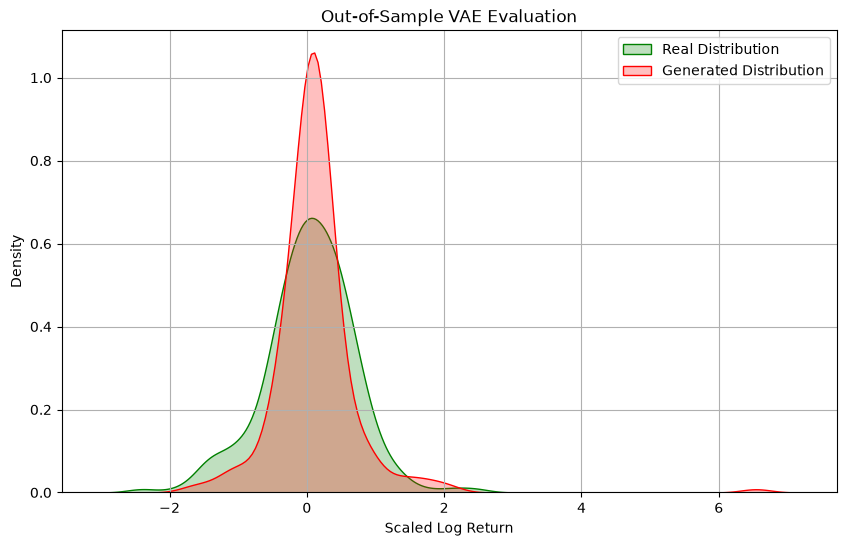

In [15]:
real_returns = X_test[:, -1, 0].numpy()
gen_returns = generated_data[:, -1, 0].numpy()

plt.figure(figsize=(10, 6))
sns.kdeplot(real_returns, fill=True, color="green", label="Real Distribution")
sns.kdeplot(gen_returns, fill=True, color="red", label="Generated Distribution")
plt.title("Out-of-Sample VAE Evaluation")
plt.xlabel("Scaled Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

In [16]:
STARTING_CAPITAL = 10000
NUM_SIMULATIONS = 1000
DAYS_FORWARD = SEQ_LEN


Worst Case Scenario: $8,857.82
Average Expected Value: $10,446.88
Best Case Scenario: $13,266.49
Probability of Profit: 86.00%
Expected Annual Yield: 73.47%


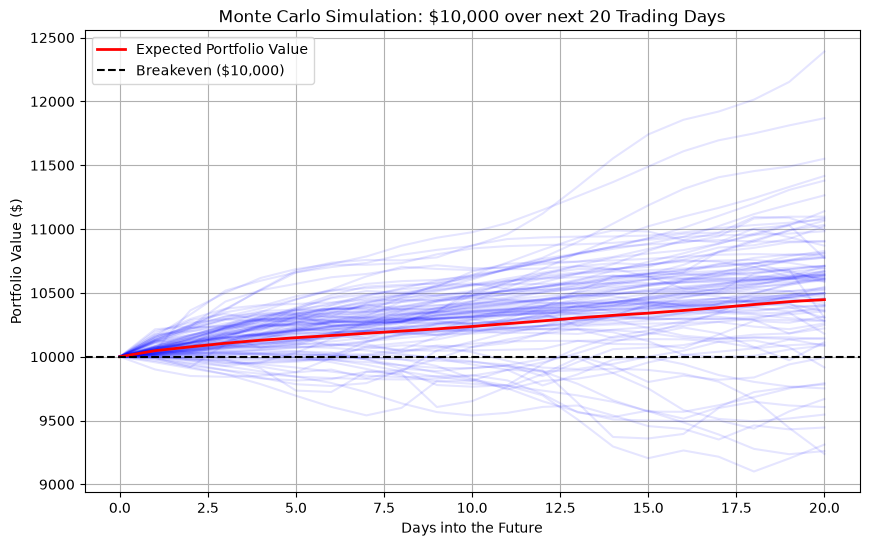

In [17]:
with torch.no_grad():
    _, mu_all, _ = model(X_test)
    empirical_std = mu_all.std(dim=0)
    current_market_state = X_test[-1].unsqueeze(0)
    _, mu_today, _ = model(current_market_state)
    z_sim = torch.randn(NUM_SIMULATIONS, LATENT_DIM) * empirical_std + mu_today
    future_paths_scaled = model.decode(z_sim).numpy()

simulated_scaled_returns = future_paths_scaled[:, :, 0]

dummy = np.zeros((NUM_SIMULATIONS * DAYS_FORWARD, 2))
dummy[:, 0] = simulated_scaled_returns.flatten()
real_log_returns = scaler.inverse_transform(dummy)[:, 0]
real_log_returns = real_log_returns.reshape(NUM_SIMULATIONS, DAYS_FORWARD)

equity_curves = np.zeros((NUM_SIMULATIONS, DAYS_FORWARD + 1))
equity_curves[:, 0] = STARTING_CAPITAL

for t in range(1, DAYS_FORWARD + 1):
    daily_multiplier = np.exp(real_log_returns[:, t-1])
    equity_curves[:, t] = equity_curves[:, t-1] * daily_multiplier

final_values = equity_curves[:, -1]
expected_value = np.mean(final_values)

period_return = (expected_value - STARTING_CAPITAL) / STARTING_CAPITAL
annualized_return = ((1 + period_return) ** (252 / DAYS_FORWARD)) - 1

print(f"\nWorst Case Scenario: ${np.min(final_values):,.2f}")
print(f"Average Expected Value: ${expected_value:,.2f}")
print(f"Best Case Scenario: ${np.max(final_values):,.2f}")
print(f"Probability of Profit: {(np.sum(final_values > STARTING_CAPITAL) / NUM_SIMULATIONS) * 100:.2f}%")
print(f"Expected Annual Yield: {annualized_return * 100:.2f}%")

plt.figure(figsize=(10, 6))
for i in range(100):
    plt.plot(equity_curves[i], color='blue', alpha=0.1)

plt.plot(np.mean(equity_curves, axis=0), color='red', linewidth=2, label="Expected Portfolio Value")

plt.title("Monte Carlo Simulation: $10,000 over next 20 Trading Days")
plt.xlabel("Days into the Future")
plt.ylabel("Portfolio Value ($)")
plt.axhline(STARTING_CAPITAL, color='black', linestyle='--', label="Breakeven ($10,000)")
plt.legend()
plt.grid(True)